# Business Analytics — Assignment 2, Part B: Managerial User Study
## Would credit managers trust an AI to tell them which borrower might default?

After building the **ABC Ltd Loan Default Risk Advisor**, 36 decision-makers reviewed the tool and answered a mixed-method survey. Respondents were branch managers, credit and loan officers, relationship managers, credit and risk heads, managers of cooperative banks and credit societies, entrepreneurs, and working professionals.
- **18 Likert items** measuring 8 constructs (usefulness, ease of use, trust, explainability, fear of a wrong decision, preference for intuition, organisational support, intention to use)
- **1 scenario** where the AI and the manager's experience disagree
- **11 open-ended questions**

> ⚠️ **Data note:** the responses in `survey_responses.csv` are **synthetic placeholder data** generated by `generate_synthetic_survey.py` to build and test this analysis. Replace the file with your real Google Form export (same column names) and re-run every cell — all tables, charts and themes will update.

## 1. Load data

In [3]:
import warnings; warnings.filterwarnings("ignore")
import os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
sns.set_theme(style="whitegrid")

# In Colab: upload survey_responses.csv to the Files panel (left sidebar), OR put your GitHub username below
GITHUB_USER = "YOUR_GITHUB_USERNAME_HERE" # <--- REPLACE WITH YOUR GITHUB USERNAME IF YOU FORKED THE REPO
GITHUB_CSV = f"https://raw.githubusercontent.com/{GITHUB_USER}/abc-loan-risk-advisor/main/survey/survey_responses.csv"
LOCAL = [p for p in ["survey_responses.csv", "../survey/survey_responses.csv", "survey/survey_responses.csv"] if os.path.exists(p)]
df = pd.read_csv(LOCAL[0] if LOCAL else GITHUB_CSV)
print(df.shape)
df.head(3)

(36, 37)


,RespondentID,Role,ExperienceYears,Organisation,LoanDecisionsPerMonth,AIUseFrequency,ReviewMode,PU1,PU2,PU3,...,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11
0,R01,Credit / Loan Officer,4,NBFC,51–200,Daily,Watched a demo,4,5,4,...,I'd use the what-if feature to structure loans...,Clean and quick to use.,No agri or seasonal cash-flow inputs. No optio...,Half-half. A few drivers look like quirks of o...,Other branch managers vouching for it after us...,Ask for a margin deposit and then approve. Ref...,"The model feels like a black box, and audit as...",Not much for me; I care whether it has been ri...,"Yes, which is why I'd use it to decide conditi...",Resistance from senior staff used to manual ap...
1,R02,Credit / Risk Head,17,NBFC,200+,Monthly,Watched a demo,5,4,4,...,Only if it is validated on our own portfolio f...,The drivers list matches what we see in practi...,Currency units are generic; should match our l...,Somewhat. The false alarms bother me — I would...,An independent validation for bias against wea...,Do a field visit and meet the family again.,They remember cases where the scorecard reject...,"Yes, but keep it short — three reasons are eno...",It does; officers prefer to be wrong with thei...,Low digital literacy in rural branches.
2,R03,Branch Manager,14,Public sector bank,200+,Monthly,Used it myself,4,3,3,...,Perhaps for portfolio monitoring rather than i...,The template download for batch scoring.,No option to record the final decision and out...,"I trust it for patterns across the portfolio, ...",A clear note on what the model can't see.,"Probably approve, but with a shorter tenure.",Admitting a model knows better can feel like a...,"Yes, explanations matter more to me than the a...",A little. But ignoring a warning that turns ou...,Customer privacy and data protection concerns....


## 2. Respondent profile

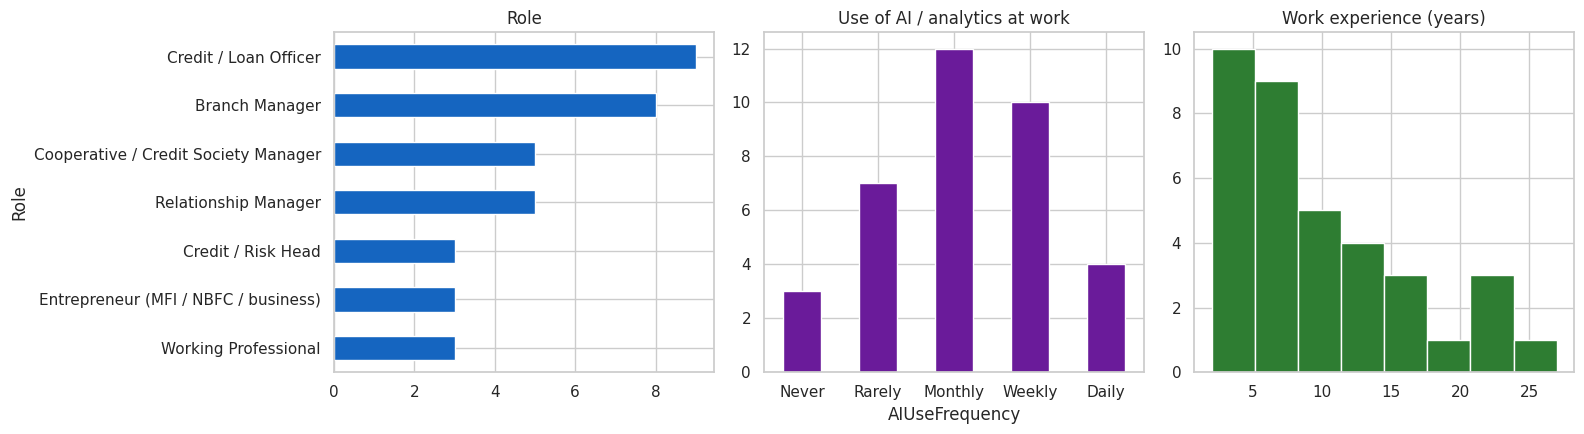

Median experience: 8 years | Organisation types: 6 | Used tool themselves: 53%


Organisation,Cooperative bank / credit society,Fintech,Microfinance,NBFC,Private bank,Public sector bank
Role,,,,,,
Branch Manager,3,0,0,0,1,4
Cooperative / Credit Society Manager,5,0,0,0,0,0
Credit / Loan Officer,0,0,1,2,4,2
Credit / Risk Head,0,0,0,2,1,0
Entrepreneur (MFI / NBFC / business),0,1,2,0,0,0
Relationship Manager,0,0,0,2,3,0
Working Professional,0,1,0,0,2,0


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
df.Role.value_counts().plot.barh(ax=ax[0], color="#1565c0"); ax[0].set_title("Role"); ax[0].invert_yaxis()
order = ["Never", "Rarely", "Monthly", "Weekly", "Daily"]
df.AIUseFrequency.value_counts().reindex(order).fillna(0).plot.bar(ax=ax[1], color="#6a1b9a")
ax[1].set_title("Use of AI / analytics at work"); ax[1].tick_params(axis="x", rotation=0)
ax[2].hist(df.ExperienceYears, bins=8, color="#2e7d32"); ax[2].set_title("Work experience (years)")
plt.tight_layout(); plt.show()

print(f"Median experience: {df.ExperienceYears.median():.0f} years | "
      f"Organisation types: {df.Organisation.nunique()} | Used tool themselves: {(df.ReviewMode=='Used it myself').mean():.0%}")
pd.crosstab(df.Role, df.Organisation)

## 3. Likert items

In [5]:
CONSTRUCTS = {
    "Usefulness": ["PU1", "PU2", "PU3"], "Ease of use": ["EU1", "EU2"],
    "Trust": ["TR1", "TR2", "TR3"], "Explainability": ["EX1", "EX2"],
    "Fear of wrong decision": ["FR1", "FR2"], "Preference for intuition": ["IN1", "IN2"],
    "Org. support": ["OS1", "OS2"], "Intention to use": ["BI1", "BI2"],
}
ITEM_TEXT = {
    "PU1": "Helps identify risky applicants earlier", "PU2": "Loan-amount check is useful",
    "PU3": "Improves my credit decisions", "EU1": "Easy without technical knowledge",
    "EU2": "Risk bands & decisions are clear", "TR1": "I trust the risk score", "TR2": "I'd rely on it to decide",
    "TR3": "Accuracy good enough for credit", "EX1": "Seeing 'why' makes me more willing",
    "EX2": "Won't act on what I can't explain to committee", "FR1": "Worry about accountability if loan turns bad",
    "FR2": "Fear makes me cautious", "IN1": "My experience of borrowers beats a model",
    "IN2": "I'd go with my judgement", "OS1": "Org has the clean data",
    "OS2": "Org encourages AI / analytics use", "BI1": "I would use this tool", "BI2": "I'd recommend it",
}
items = [i for v in CONSTRUCTS.values() for i in v]
desc = pd.DataFrame({
    "statement": [ITEM_TEXT[i] for i in items],
    "mean": df[items].mean().round(2), "sd": df[items].std().round(2),
    "% agree (4-5)": (df[items] >= 4).mean().mul(100).round(0),
    "% disagree (1-2)": (df[items] <= 2).mean().mul(100).round(0),
})
desc

,statement,mean,sd,% agree (4-5),% disagree (1-2)
PU1,Helps identify risky applicants earlier,3.86,0.80,72.0,6.0
PU2,Loan-amount check is useful,3.47,0.81,44.0,8.0
PU3,Improves my credit decisions,3.81,0.75,67.0,3.0
EU1,Easy without technical knowledge,4.17,0.56,92.0,0.0
EU2,Risk bands & decisions are clear,4.00,0.76,72.0,0.0
TR1,I trust the risk score,3.00,0.96,28.0,28.0
TR2,I'd rely on it to decide,2.78,1.07,31.0,44.0
TR3,Accuracy good enough for credit,3.08,0.91,36.0,28.0
EX1,Seeing 'why' makes me more willing,4.44,0.56,97.0,0.0
EX2,Won't act on what I can't explain to committee,4.33,0.59,94.0,0.0


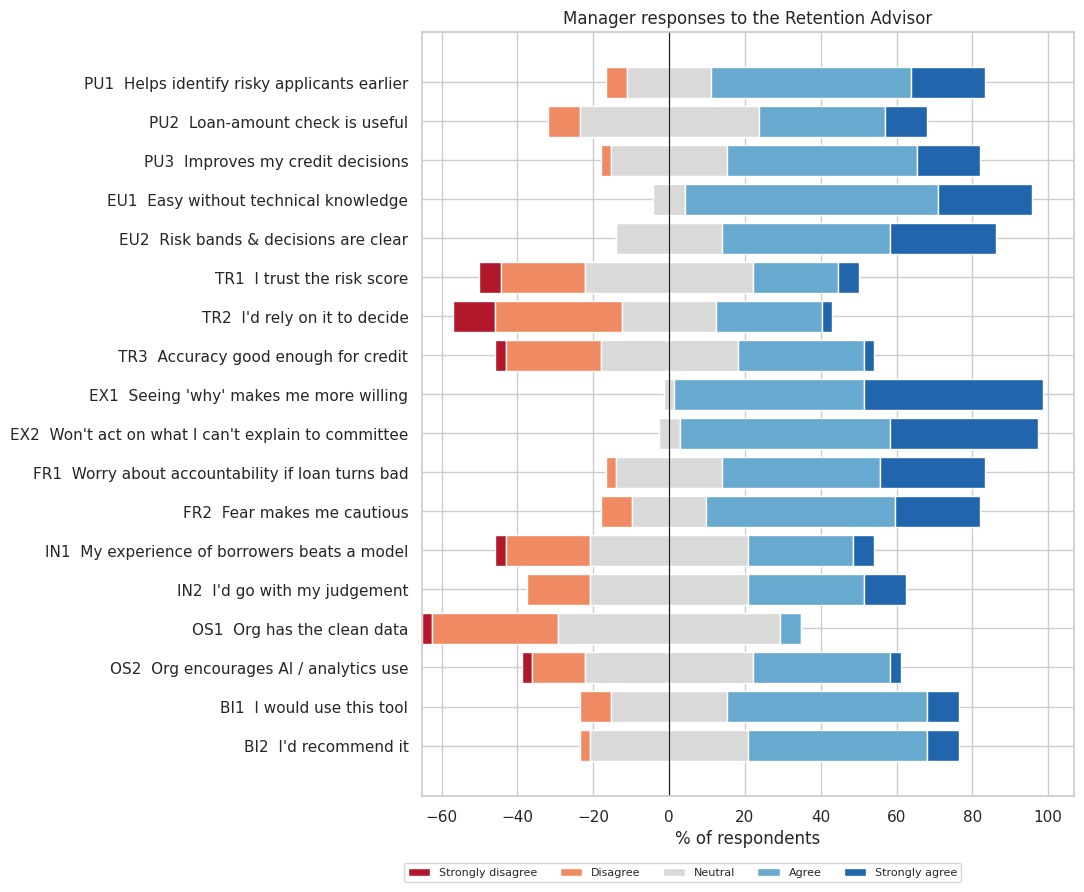

In [6]:
# Diverging stacked bar chart
cols = {1: "#b2182b", 2: "#ef8a62", 3: "#d9d9d9", 4: "#67a9cf", 5: "#2166ac"}
pct = pd.DataFrame({k: (df[items] == k).mean() * 100 for k in range(1, 6)})
pct.index = [f"{i}  {ITEM_TEXT[i]}" for i in items]
left = -(pct[1] + pct[2] + pct[3] / 2)
fig, ax = plt.subplots(figsize=(11, 9))
start = left.copy()
for k in range(1, 6):
    ax.barh(pct.index, pct[k], left=start, color=cols[k],
            label=["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"][k-1])
    start += pct[k]
ax.axvline(0, color="k", lw=.8); ax.invert_yaxis(); ax.set_xlabel("% of respondents")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(.4, -.12), fontsize=8)
ax.set_title("Manager responses to the Retention Advisor"); plt.tight_layout(); plt.show()

## 4. Construct scores and reliability (Cronbach's α)

In [7]:
def cronbach_alpha(x: pd.DataFrame) -> float:
    k = x.shape[1]
    return k / (k - 1) * (1 - x.var(ddof=1).sum() / x.sum(axis=1).var(ddof=1))

for c, its in CONSTRUCTS.items():
    df[c] = df[its].mean(axis=1)

rel = pd.DataFrame({
    "items": [len(v) for v in CONSTRUCTS.values()],
    "alpha": [cronbach_alpha(df[v]) for v in CONSTRUCTS.values()],
    "mean": [df[c].mean() for c in CONSTRUCTS], "sd": [df[c].std() for c in CONSTRUCTS],
}, index=list(CONSTRUCTS)).round(2)
rel["reliability"] = pd.cut(rel.alpha, [-1, .6, .7, .8, 1], labels=["Poor", "Acceptable (exploratory)", "Good", "Very good"])
rel

,items,alpha,mean,sd,reliability
Usefulness,3,0.82,3.71,0.67,Very good
Ease of use,2,0.56,4.08,0.55,Poor
Trust,3,0.90,2.95,0.89,Very good
Explainability,2,0.74,4.39,0.51,Good
Fear of wrong decision,2,0.77,3.90,0.76,Good
Preference for intuition,2,0.83,3.24,0.84,Very good
Org. support,2,0.76,2.94,0.66,Good
Intention to use,2,0.84,3.61,0.68,Very good


α ≥ 0.7 is conventionally good; 0.6–0.7 is acceptable for an exploratory study with 2–3 items per construct and a small sample.

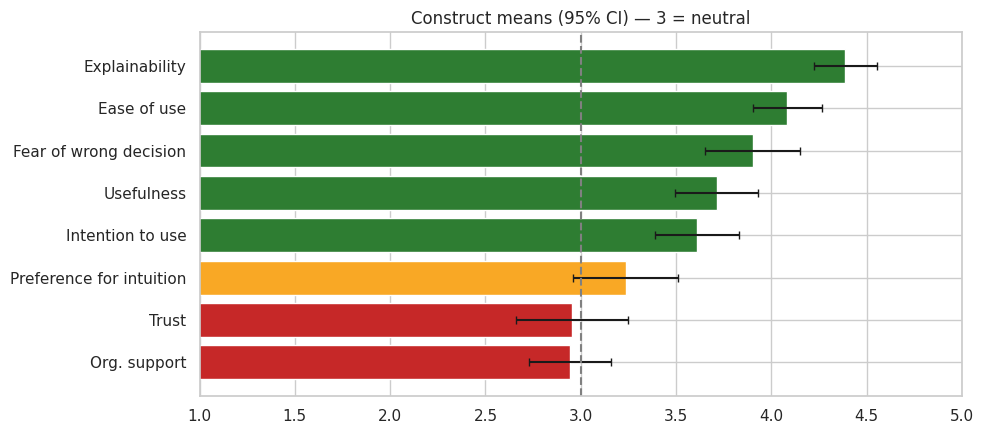

In [8]:
CON = list(CONSTRUCTS)
fig, ax = plt.subplots(figsize=(10, 4.5))
m = df[CON].mean().sort_values()
ax.barh(m.index, m, color=["#c62828" if v < 3 else "#f9a825" if v < 3.5 else "#2e7d32" for v in m],
        xerr=df[CON].std()[m.index] / np.sqrt(len(df)) * 1.96, capsize=3)
ax.axvline(3, ls="--", color="grey"); ax.set_xlim(1, 5); ax.set_title("Construct means (95% CI) — 3 = neutral")
plt.tight_layout(); plt.show()

## 5. Differences between groups

In [9]:
df["ExpGroup"] = pd.cut(df.ExperienceYears, [0, 7, 15, 40], labels=["≤7 yrs", "8–15 yrs", ">15 yrs"])
df["AIUser"] = np.where(df.AIUseFrequency.isin(["Weekly", "Daily"]), "Frequent AI user", "Occasional / non-user")

by_role = df.groupby("Role")[CON].mean().round(2)
by_org = df.groupby("Organisation")[CON].mean().round(2)
display(by_role)
by_org

,Usefulness,Ease of use,Trust,Explainability,Fear of wrong decision,Preference for intuition,Org. support,Intention to use
Role,,,,,,,,
Branch Manager,3.33,3.94,2.67,4.19,4.00,3.75,2.81,3.44
Cooperative / Credit Society Manager,3.53,3.80,2.73,4.10,3.20,3.70,2.50,3.60
Credit / Loan Officer,4.04,4.22,2.93,4.61,3.83,3.06,3.39,3.39
Credit / Risk Head,3.56,3.67,1.89,4.33,4.50,4.17,2.17,2.50
Entrepreneur (MFI / NBFC / business),3.33,4.17,3.33,4.00,4.17,2.17,3.00,4.33
Relationship Manager,3.80,4.20,3.47,4.80,4.20,2.60,3.00,4.00
Working Professional,4.44,4.67,4.00,4.50,3.67,2.83,3.33,4.50


,Usefulness,Ease of use,Trust,Explainability,Fear of wrong decision,Preference for intuition,Org. support,Intention to use
Organisation,,,,,,,,
Cooperative bank / credit society,3.46,3.88,2.62,4.19,3.50,3.56,2.50,3.56
Fintech,3.33,4.75,4.00,4.25,4.25,3.25,3.00,4.25
Microfinance,3.78,4.00,3.11,4.17,4.33,2.33,3.00,4.00
NBFC,3.83,4.08,2.72,4.58,4.25,2.92,2.67,3.33
Private bank,3.97,4.14,2.97,4.55,3.77,3.23,3.36,3.55
Public sector bank,3.56,4.08,3.17,4.33,4.00,3.58,3.00,3.67


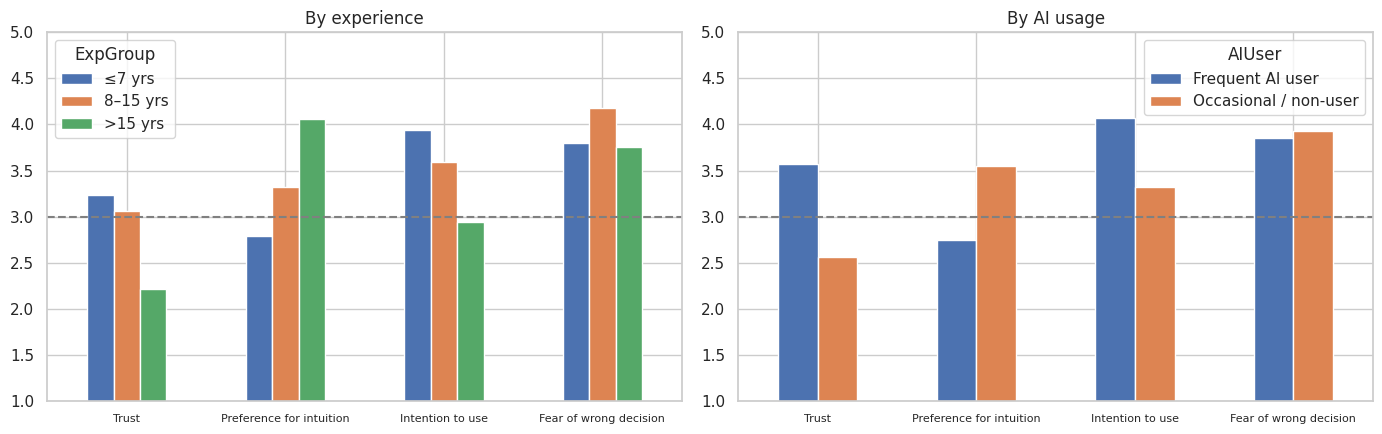

,construct,AI users mean,others mean,Mann-Whitney p,Experience Kruskal-Wallis p
0,Usefulness,4.048,3.500,0.012,0.084
1,Ease of use,4.250,3.977,0.150,0.042
2,Trust,3.571,2.561,0.001,0.032
3,Explainability,4.393,4.386,1.000,0.173
4,Fear of wrong decision,3.857,3.932,0.764,0.209
5,Preference for intuition,2.750,3.545,0.005,0.001
6,Org. support,3.143,2.818,0.238,0.082
7,Intention to use,4.071,3.318,0.001,0.002


In [10]:
key = ["Trust", "Preference for intuition", "Intention to use", "Fear of wrong decision"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
df.groupby("ExpGroup", observed=True)[key].mean().T.plot.bar(ax=ax[0], rot=0); ax[0].set_title("By experience"); ax[0].set_ylim(1, 5)
df.groupby("AIUser")[key].mean().T.plot.bar(ax=ax[1], rot=0); ax[1].set_title("By AI usage"); ax[1].set_ylim(1, 5)
for a in ax: a.axhline(3, ls="--", color="grey"); a.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

rows = []
for c in CON:
    g = [df.loc[df.AIUser == k, c] for k in ["Frequent AI user", "Occasional / non-user"]]
    u = stats.mannwhitneyu(*g)
    e = [df.loc[df.ExpGroup == k, c] for k in df.ExpGroup.cat.categories]
    kw = stats.kruskal(*e)
    rows.append({"construct": c, "AI users mean": g[0].mean(), "others mean": g[1].mean(),
                 "Mann-Whitney p": u.pvalue, "Experience Kruskal-Wallis p": kw.pvalue})
tests = pd.DataFrame(rows).round(3)
tests

Non-parametric tests are used because Likert scores are ordinal and the groups are small. With n = 32, treat p-values as indicative, not conclusive.

## 6. What drives the intention to use the tool?

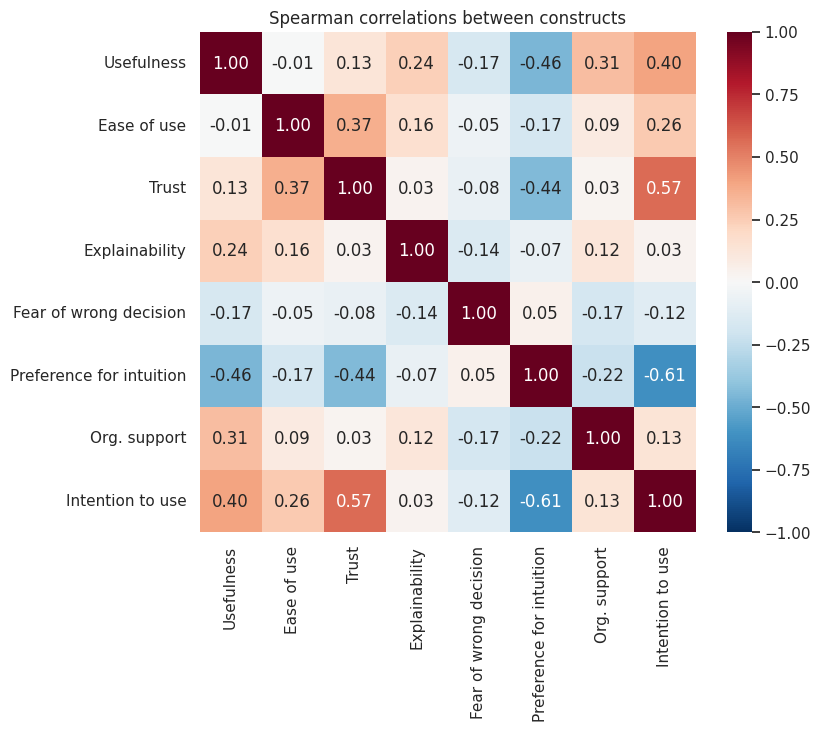

In [11]:
corr = df[CON].corr(method="spearman")
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlations between constructs"); plt.show()

In [12]:
reg = df.rename(columns=lambda c: c.replace(" ", "_").replace(".", ""))
model = smf.ols("Intention_to_use ~ Usefulness + Trust + Explainability + Fear_of_wrong_decision"
                " + Preference_for_intuition + Org_support", data=reg).fit()
print(model.summary().tables[1])
print(f"\nR² = {model.rsquared:.2f}, adj. R² = {model.rsquared_adj:.2f}, n = {int(model.nobs)}")

                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    3.7113      1.332      2.786      0.009       0.987       6.436
Usefulness                   0.2391      0.149      1.605      0.119      -0.066       0.544
Trust                        0.2617      0.109      2.404      0.023       0.039       0.484
Explainability              -0.1024      0.175     -0.586      0.562      -0.460       0.255
Fear_of_wrong_decision      -0.0824      0.116     -0.709      0.484      -0.320       0.155
Preference_for_intuition    -0.2948      0.128     -2.310      0.028      -0.556      -0.034
Org_support                 -0.0122      0.137     -0.089      0.930      -0.293       0.269

R² = 0.54, adj. R² = 0.44, n = 36


With 32 respondents and 6 predictors this regression is **exploratory** — it shows the direction and relative size of each factor, which we then check against what managers wrote in the open-ended answers.

## 7. Scenario: the tool says 68% default risk, but you know the family and trust them

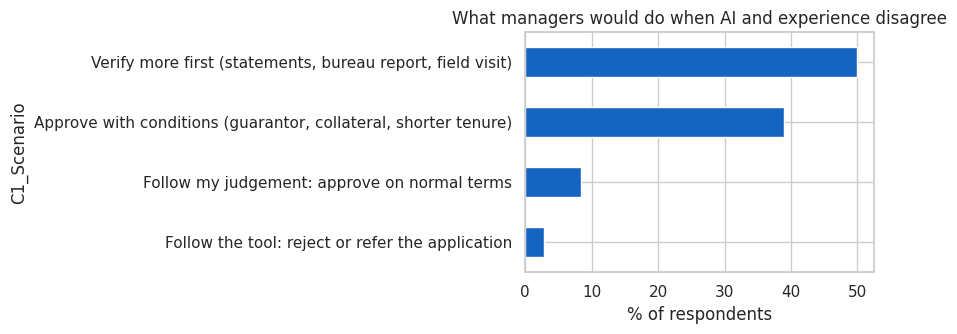

IntuitionLevel,High intuition preference,Low / moderate,All
C1_Scenario,,,
"Approve with conditions (guarantor, collateral, shorter tenure)",6,8,14
Follow my judgement: approve on normal terms,1,2,3
Follow the tool: reject or refer the application,0,1,1
"Verify more first (statements, bureau report, field visit)",8,10,18
All,15,21,36


In [13]:
sc = df.C1_Scenario.value_counts()
fig, ax = plt.subplots(figsize=(9, 3.5))
(sc / len(df) * 100).sort_values().plot.barh(ax=ax, color="#1565c0"); ax.set_xlabel("% of respondents")
ax.set_title("What managers would do when AI and experience disagree"); plt.tight_layout(); plt.show()

df["IntuitionLevel"] = np.where(df["Preference for intuition"] >= 3.5, "High intuition preference", "Low / moderate")
pd.crosstab(df.C1_Scenario, df.IntuitionLevel, margins=True)

## 8. Qualitative analysis of open-ended answers

**Method.** The open-ended questions are analysed in two groups:
- **Q1–Q7 (feedback on the tool)** — managers raise whatever matters to them, so these are coded into 9 cross-cutting themes and counted **once per respondent per theme**. This shows what managers bring up *unprompted*.
- **Q8–Q11 (prompted questions on intuition, explainability, fear and barriers)** — each already names a theme, so counting that theme would be circular. Instead each answer is coded into question-specific categories (reasons, stance, barriers).

Coding uses keyword rules (below). This is a transparent, repeatable version of manual thematic coding — when you have real data, read through the coded answers and adjust the keywords where the rules miss or over-match.

In [14]:
QTEXT = {
    "Q1": "How useful is the tool for credit managers?", "Q2": "Would you use it? Why?",
    "Q3": "What do you like?", "Q4": "What do you dislike / find missing?",
    "Q5": "Do you trust the prediction? Why?", "Q6": "What would make you trust AI more?",
    "Q7": "If AI and experience differ, what would you do?", "Q8": "Why do managers prefer intuition?",
    "Q9": "Does explainability matter?", "Q10": "Does fear of a wrong decision matter?",
    "Q11": "What discourages AI adoption?",
}
THEMES = {
    "Explainability & transparency": r"\bwhy\b|reason|explain|driver|black box|transparen|note on what",
    "Data gaps & integration": r"\bdata\b|income|bureau|statement|integrat|origination|entry|self-declared|seasonal",
    "Accountability, audit & regulation": r"accountab|audit|responsible|rbi|regulat|vigilance|defend|committee|policy",
    "Local context & relationships": r"local|family|know my|personally|reputation|character|crop|members|illness|foreign data|different market|borrowers are different",
    "Validation & track record": r"back-test|tested|pilot|validat|past predictions|own portfolio|our own|latest repayment|vouching",
    "Actionability & loan structuring": r"what-if|guarantor|collateral|tenure|conditions|structure|margin|filter|screen|ranking",
    "Fairness & customer impact": r"fair|bias|weaker|poorer|genuine|lose good|mechanically|sex and|privacy",
    "Accuracy & false alarms": r"false alarm|accura|misses|missing|percentage|confidence|error",
    "Ease of use & workflow": r"easy|simple|clean|quick|jargon|mobile|template|double entry|extra work",
}
QCOLS = list(QTEXT)
TOOL_Q = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7"]
long = df.melt(id_vars=["RespondentID", "Role"], value_vars=TOOL_Q, var_name="Question", value_name="Answer")
for t, pat in THEMES.items():
    long[t] = long.Answer.str.contains(pat, flags=re.I, regex=True)

per_resp = long.groupby("RespondentID")[list(THEMES)].any()
theme_freq = (per_resp.mean() * 100).sort_values(ascending=False).round(0).to_frame("% of respondents")
theme_freq["mentions"] = long[list(THEMES)].sum()
theme_freq

,% of respondents,mentions
Data gaps & integration,97.0,79
Explainability & transparency,81.0,47
Accuracy & false alarms,81.0,42
Actionability & loan structuring,78.0,76
Validation & track record,72.0,45
Ease of use & workflow,72.0,35
Fairness & customer impact,50.0,25
"Accountability, audit & regulation",39.0,24
Local context & relationships,28.0,31


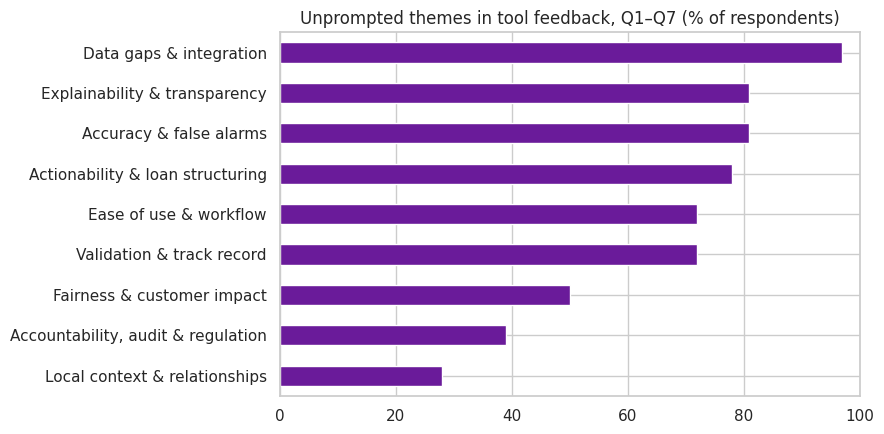

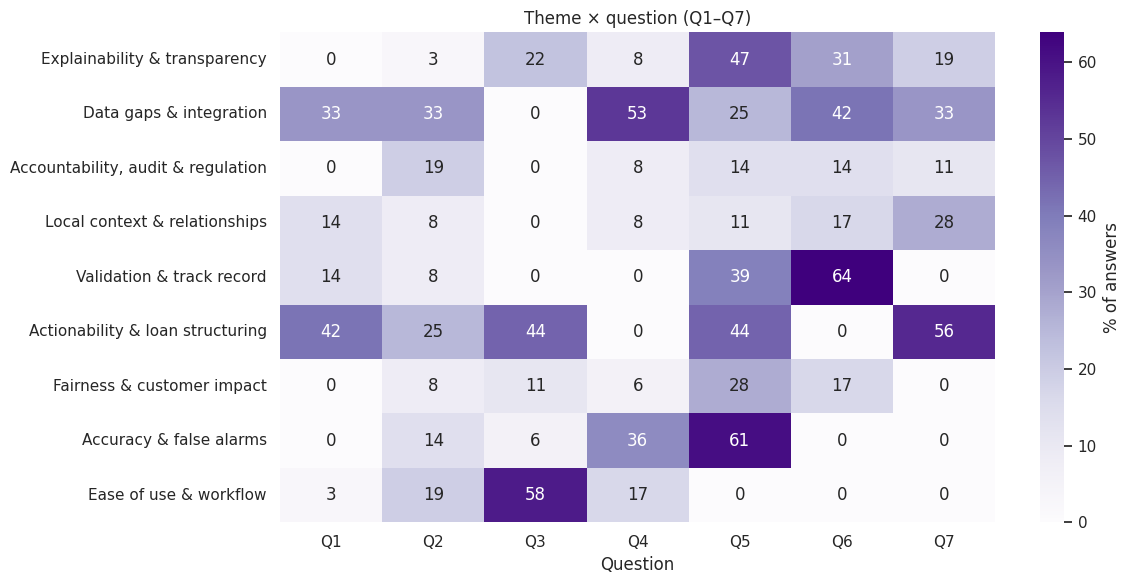

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
theme_freq["% of respondents"].sort_values().plot.barh(ax=ax, color="#6a1b9a")
ax.set_title("Unprompted themes in tool feedback, Q1–Q7 (% of respondents)"); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

# Which themes come up in which question
heat = long.groupby("Question")[list(THEMES)].mean().reindex(TOOL_Q) * 100
plt.figure(figsize=(12, 6))
sns.heatmap(heat.T, annot=True, fmt=".0f", cmap="Purples", cbar_kws={"label": "% of answers"})
plt.title("Theme × question (Q1–Q7)"); plt.tight_layout(); plt.show()

In [16]:
# Q2: would you use it? — simple stance coding
def stance(a):
    a = a.lower()
    if re.match(r"^if head office", a): return "Conditional / maybe"
    if re.match(r"^(yes|i would|definitely)", a): return "Yes"
    if re.match(r"^(no|not|probably not)", a): return "No / not yet"
    return "Conditional / maybe"
df["Q2_stance"] = df.Q2.apply(stance)
print(df.Q2_stance.value_counts())
print()
print(pd.crosstab(df.Q2_stance, df.AIUser))
print()
print("Mean intention-to-use score by stance (checks consistency of closed vs open answers):")
print(df.groupby("Q2_stance")["Intention to use"].mean().round(2))

Q2_stance
Yes                    16
Conditional / maybe    12
No / not yet            8
Name: count, dtype: int64

AIUser               Frequent AI user  Occasional / non-user
Q2_stance                                                   
Conditional / maybe                 3                      9
No / not yet                        0                      8
Yes                                11                      5

Mean intention-to-use score by stance (checks consistency of closed vs open answers):
Q2_stance
Conditional / maybe    3.42
No / not yet           2.75
Yes                    4.19
Name: Intention to use, dtype: float64


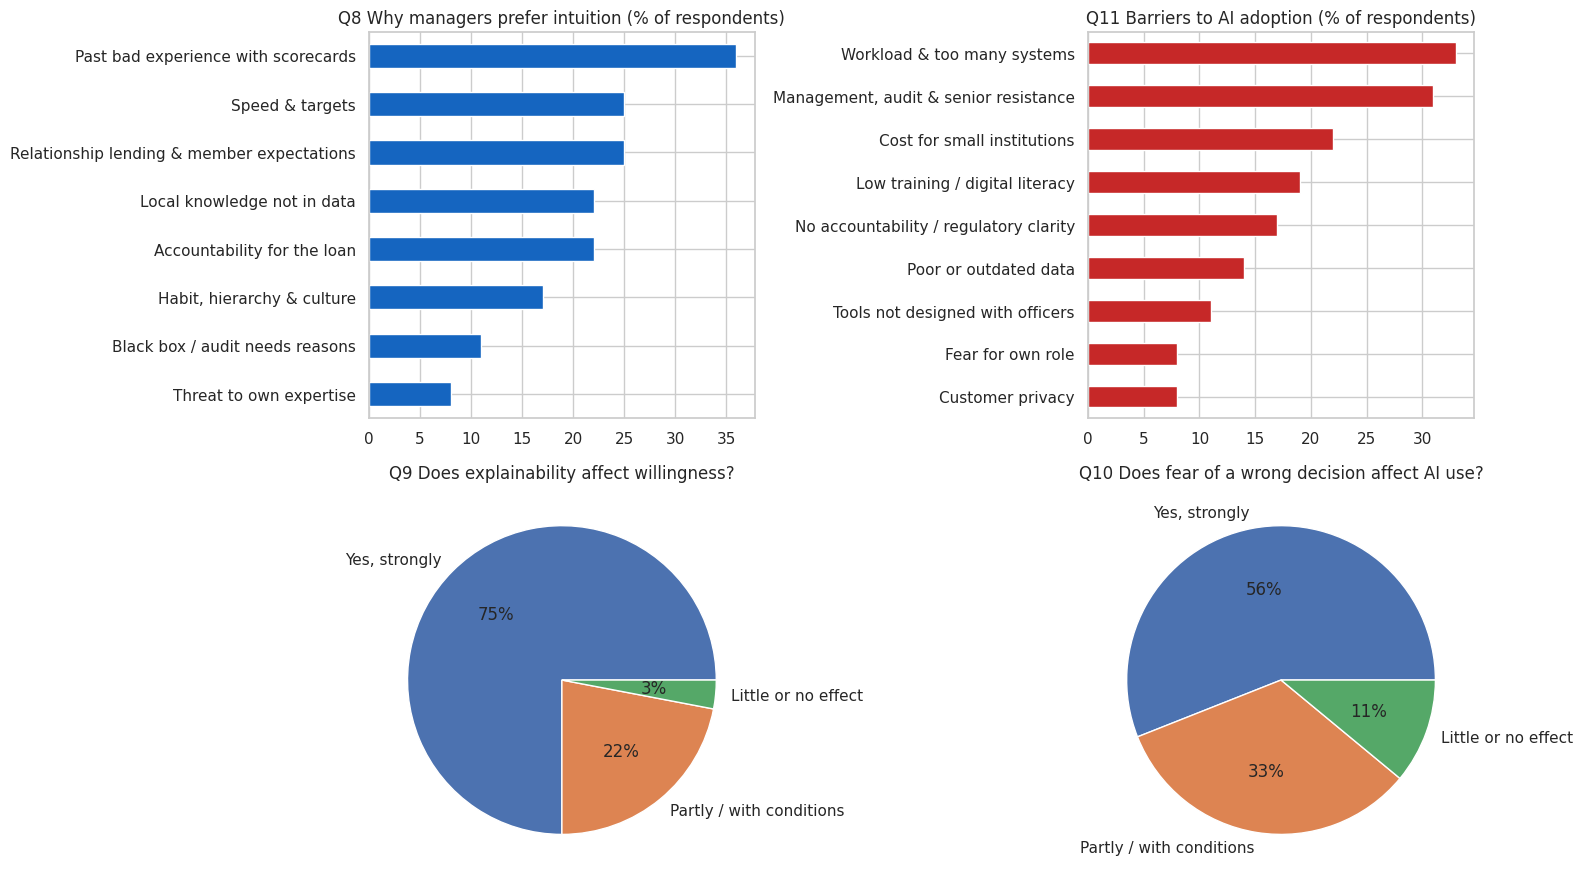

% of respondents
Q8 reasons for intuition   Past bad experience with scorecards                     36.0
                           Relationship lending & member expectations              25.0
                           Speed & targets                                         25.0
                           Accountability for the loan                             22.0
                           Local knowledge not in data                             22.0
                           Habit, hierarchy & culture                              17.0
                           Black box / audit needs reasons                         11.0
                           Threat to own expertise                                  8.0
Q9 explainability          Yes, strongly                                           75.0
                           Partly / with conditions                                22.0
                           Little or no effect                                      3.0
Q10 fear of wrong decision Yes, strongly                                           56.0
                           Partly / with conditions                                33.0
                           Little or no effect                                     11.0
Q11 barriers               Workload & too many systems                             33.0
                           Management, audit & senior resistance                   31.0
                           Cost for small institutions                             22.0
                           Low training / digital literacy                         19.0
                           No accountability / regulatory clarity                  17.0
                           Poor or outdated data                                   14.0
                           Tools not designed with officers                        11.0
                           Customer privacy                                         8.0
                           Fear for own role                                        8.0

In [17]:
# Q8–Q11: question-specific coding
Q8_CODES = {
    "Accountability for the loan": r"accountab|safer relying",
    "Local knowledge not in data": r"local knowledge|family|crop",
    "Habit, hierarchy & culture": r"habit|hierarchy|senior bankers|learned credit",
    "Black box / audit needs reasons": r"black box|audit",
    "Past bad experience with scorecards": r"scorecard|sceptical",
    "Relationship lending & member expectations": r"relationship lending|members expect|trust built",
    "Speed & targets": r"quick|targets|faster|data entry",
    "Threat to own expertise": r"threat|expertise",
}
Q11_CODES = {
    "Poor or outdated data": r"incomplete|outdated",
    "Low training / digital literacy": r"training|literacy",
    "Management, audit & senior resistance": r"senior management|audit|senior staff|manual appraisal",
    "Customer privacy": r"privacy|data protection",
    "Workload & too many systems": r"workload|recovery|disconnected|burden",
    "Fear for own role": r"reduce the role",
    "Cost for small institutions": r"cost of new|small cooperatives",
    "No accountability / regulatory clarity": r"accountability rule|regulatory",
    "Tools not designed with officers": r"built by it|without asking",
}
def code_multi(series, codes):
    hits = pd.DataFrame({k: series.str.contains(v, case=False, regex=True) for k, v in codes.items()})
    return (hits.mean() * 100).round(0).sort_values(ascending=False)

def stance3(a, yes=r"^(yes|definitely)", partly=r"^(somewhat|a little|it does|it matters|yes, but)"):
    a = a.lower()
    if re.match(r"^yes, but", a) or re.match(partly, a): return "Partly / with conditions"
    if re.match(yes, a): return "Yes, strongly"
    return "Little or no effect"

q8 = code_multi(df.Q8, Q8_CODES)
q11 = code_multi(df.Q11, Q11_CODES)
df["Q9_stance"] = df.Q9.apply(stance3)
df["Q10_stance"] = df.Q10.apply(stance3)
q9 = (df.Q9_stance.value_counts(normalize=True) * 100).round(0)
q10 = (df.Q10_stance.value_counts(normalize=True) * 100).round(0)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
q8.sort_values().plot.barh(ax=ax[0, 0], color="#1565c0"); ax[0, 0].set_title("Q8 Why managers prefer intuition (% of respondents)")
q11.sort_values().plot.barh(ax=ax[0, 1], color="#c62828"); ax[0, 1].set_title("Q11 Barriers to AI adoption (% of respondents)")
q9.plot.pie(ax=ax[1, 0], autopct="%.0f%%", ylabel=""); ax[1, 0].set_title("Q9 Does explainability affect willingness?")
q10.plot.pie(ax=ax[1, 1], autopct="%.0f%%", ylabel=""); ax[1, 1].set_title("Q10 Does fear of a wrong decision affect AI use?")
plt.tight_layout(); plt.show()

prompted = pd.concat({"Q8 reasons for intuition": q8, "Q9 explainability": q9,
                      "Q10 fear of wrong decision": q10, "Q11 barriers": q11}).rename("% of respondents").to_frame()
prompted

In [18]:
# Representative quotes per theme (shortest clear answers first)
pd.set_option("display.max_colwidth", 160)
quotes = []
for t in theme_freq.index:
    hits = long[long[t]].assign(n=lambda d: d.Answer.str.len()).sort_values("n")
    for _, r in hits.drop_duplicates("Answer").head(3).iterrows():
        quotes.append({"theme": t, "respondent": f"{r.RespondentID} ({r.Role})", "question": r.Question, "quote": r.Answer})
quotes = pd.DataFrame(quotes)
quotes

,theme,respondent,question,quote
0,Data gaps & integration,R13 (Branch Manager),Q4,No agri or seasonal cash-flow inputs.
1,Data gaps & integration,R24 (Credit / Loan Officer),Q5,Not really; missing income data is a big gap.
2,Data gaps & integration,R25 (Credit / Loan Officer),Q6,Regular updates with our latest repayment data.
3,Explainability & transparency,R12 (Working Professional),Q3,It shows the reasons behind every score.
4,Explainability & transparency,R03 (Branch Manager),Q6,A clear note on what the model can't see.
5,Explainability & transparency,R10 (Cooperative / Credit Society Manager),Q6,Being able to override it with a recorded reason.
6,Accuracy & false alarms,R24 (Credit / Loan Officer),Q5,Not really; missing income data is a big gap.
7,Accuracy & false alarms,R04 (Cooperative / Credit Society Manager),Q4,"Needs a confidence range, not just one number."
8,Accuracy & false alarms,R23 (Credit / Loan Officer),Q5,Partly. I trust the ranking more than the percentage.
9,Actionability & loan structuring,R21 (Relationship Manager),Q3,Simple screens; no jargon.


## 9. Export results

In [19]:
from openpyxl.styles import Font, PatternFill, Alignment

out = "survey_analysis.xlsx"
codebook = pd.DataFrame(
    [(c, i, ITEM_TEXT[i]) for c, its in CONSTRUCTS.items() for i in its] +
    [("Open-ended", q, t) for q, t in QTEXT.items()] +
    [("Scenario", "C1_Scenario", "Known local customer; tool says 68% default risk. What would you do?")],
    columns=["construct", "code", "question"])

with pd.ExcelWriter(out, engine="openpyxl") as xw:
    df.drop(columns=CON + ["ExpGroup", "AIUser", "IntuitionLevel", "Q2_stance", "Q9_stance", "Q10_stance"]).to_excel(xw, sheet_name="Responses", index=False)
    codebook.to_excel(xw, sheet_name="Codebook", index=False)
    desc.to_excel(xw, sheet_name="Likert items")
    rel.to_excel(xw, sheet_name="Constructs & alpha")
    by_role.to_excel(xw, sheet_name="By role")
    by_org.to_excel(xw, sheet_name="By organisation")
    tests.to_excel(xw, sheet_name="Group tests", index=False)
    pd.DataFrame({"coef": model.params, "p_value": model.pvalues}).round(3).to_excel(xw, sheet_name="Regression")
    pd.crosstab(df.C1_Scenario, df.IntuitionLevel, margins=True).to_excel(xw, sheet_name="Scenario")
    theme_freq.to_excel(xw, sheet_name="Themes")
    prompted.to_excel(xw, sheet_name="Prompted Qs")
    quotes.to_excel(xw, sheet_name="Quotes", index=False)
    for ws in xw.book.worksheets:
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF"); cell.fill = PatternFill("solid", fgColor="1565C0")
        for col in ws.columns:
            width = min(max(len(str(c.value or "")) for c in col) + 2, 70)
            ws.column_dimensions[col[0].column_letter].width = width
            for c in col[1:]:
                c.alignment = Alignment(wrap_text=width >= 70, vertical="top")
        ws.freeze_panes = "A2"
print("Saved", out)

Saved survey_analysis.xlsx


## 10. Findings

*(These numbers describe the current dataset. If you replace it with real responses, update this section from the outputs above.)*

### What credit managers think of the tool
1. **Easy to use and useful for screening, but not yet trusted.** 92% found it easy to understand, and 72% said it helps identify risky applicants earlier. Trust sits right at neutral (mean 3.0). Only **31% would rely on the prediction when deciding**, and 44% said they would not.
2. **The amount check was the least valued feature** (44% agree). This matches the model result: requests far above the typical amount did not default more often.
3. **Adoption splits by experience with analytics.** In the open answers, 44% said "yes" outright, 33% gave a conditional "maybe", and 22% said "no / not yet". Frequent AI users were far more positive: intention to use 4.1 vs 3.3 (p = 0.001).

### What drives willingness to use AI in lending
4. **Trust and intuition decide intention; explainability is a precondition.** In the regression (R² = 0.54), **trust raises intention** (β = 0.26, p = 0.02) and **preference for one's own judgement lowers it** (β = −0.29, p = 0.03). Explainability scored highest of all constructs (mean 4.4): 97% said seeing the reasons makes them more willing, and 94% would not act on a score they cannot explain to the credit committee. Because almost everyone agrees, it doesn't separate adopters from non-adopters. It is a *hygiene factor* for any credit tool.
5. **Credit officers use AI to structure loans, not to reject them.** When the tool said 68% risk for a customer they knew and trusted, only **3% would follow the tool** and 8% would approve on normal terms. **50% would verify more** (statements, bureau report, field visit), and **39% would approve with conditions** such as a guarantor, collateral or a shorter tenure. The what-if panel fits exactly how they want to work.
6. **Fear of accountability is strong in lending** (mean 3.9). 69% worry about being held accountable if an AI-assisted loan turns bad, higher than in typical workplace settings. Staff accountability, audit and NPA reviews came up repeatedly. Some respondents added that a documented tool could *protect* them in an audit.
7. **Experience strengthens intuition and lowers trust.** Preference for one's own judgement rises from 2.8 (≤7 years) to 4.1 (>15 years), and trust falls from 3.2 to 2.2 (p < 0.05). The most common reason given was past bad experience with scorecards, followed by relationship lending and the need for speed under sanction targets.

### Barriers
8. **Data readiness is the weakest link.** Only 6% said their organisation has the clean data such a tool needs. Data gaps (income, bureau score, bank statements, integration with loan systems) were raised by almost every respondent (97%).
9. **Cooperatives are the most cautious** (lowest trust 2.6, lowest organisational support 2.5, high intuition 3.6). Members expect a human decision, and local knowledge matters. Fintech and microfinance respondents were the most open.
10. **Named barriers:** workload and too many disconnected systems, audit and senior-management resistance, the cost for small institutions, and unclear accountability or regulatory guidance.

### Implications for the tool and its rollout
| Finding | Change to the tool / rollout |
|---|---|
| Trust is low; managers want proof on *their* loans | Back-test on ABC Ltd's own portfolio and show past predictions next to outcomes; pilot in one region |
| Missing inputs (income, bureau, statements) | Add EMI-to-income and bureau score fields; integrate with the loan origination system |
| Officers want to structure, not reject | Make the what-if panel the centre of the screen; record the conditions chosen |
| Fear of accountability | Credit policy note: the score triggers verification, the officer owns the decision, and overrides are recorded with reasons |
| Explanations are essential for committees and audit | Auto-generate a 3-line credit-note summary of the drivers for each file |
| Cooperatives and senior officers are sceptical | Involve them in design; add local variables (seasonality, group guarantees) |

### Limitations
- **The responses in this notebook are synthetic** and must be replaced with real survey data before drawing conclusions.
- n = 36 is small; the regression and group tests are exploratory.
- Stated intentions usually overstate actual use.
- Keyword-based coding is a first pass; real answers should be read and the coding frame refined.